# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



# Most Likely to Survive
* Name: Miss Hedwig Margaritha Frolicher
* Age: 22
* Fare: 49.5
* Sex: Female
* Passenger Class: 1
* Travel Companions: 2 Parents
* Port of Departure: C - Cherbourg
* Interesting Fact: There wasn't much about her but the thing I found most interesting was she was aboard the Titanic to travel to New York to mee her future husband.

# Least Likely to survive
* Name: Mr. Karl Alfred Backstrom
* Age: 32
* Fare: 15.85
* Sex: Male
* Passenger Class: 3
* Travel Companions: 1 Spouse
* Port of Departure: S - Southampton
* Interesting Fact: Was traveling to the USA because he got a job offer as a construction foreman. His body was also never found.


The reason I chose the variables I did was solely based on what the graphs had shown. When it comes to the most likely to survive, when looking at the age graphs, 20-35 is where the most survivors ages fell. Being a female had a far greater chance of survival so we limited it to female only. When it comes to the class, 1st class had far more survivors then deaths so it makes sense to limit the class to 1. When looking at the fare, I'd say the majority of survivors were within the 10 to 50 range, some paid much higher but we wanted the largest selection so this is where I set my limit. The C port had far more survivals versus deaths so I wanted to limit it to that port specifically. Lastly with spouses/ siblings and parents/ children, the greatest survival odds were if you at least had 1 to 2.

This same method is what took me to the variables I chose for the least likely to survive except I just took in the values that had the most deaths.

In [4]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

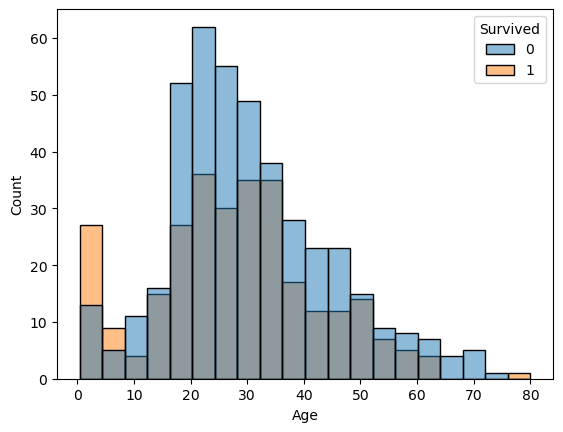

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(x='Age', data=df, hue='Survived')

plt.show()

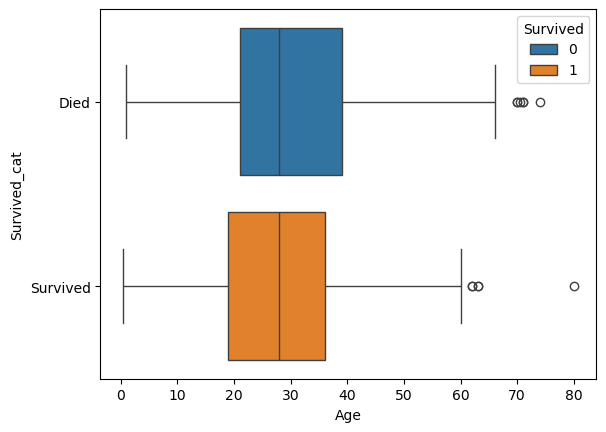

In [7]:
df.loc[df['Survived'] == 0, 'Survived_cat'] = 'Died'
df.loc[df['Survived'] == 1, 'Survived_cat'] = 'Survived'

sns.boxplot(x='Age', data=df, y='Survived_cat', hue='Survived')
plt.show()

In [8]:
df['Survived'].dtype

dtype('int64')

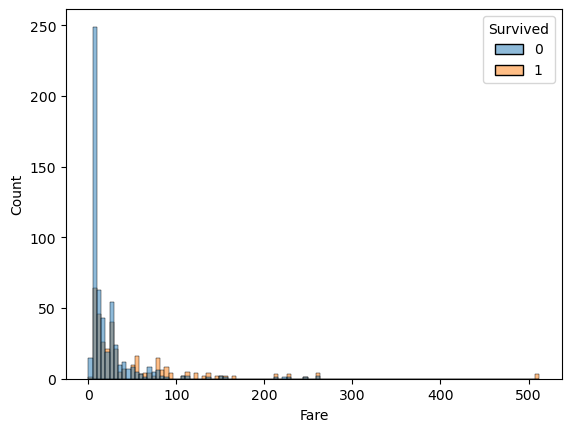

In [9]:
sns.histplot(x='Fare', data=df, hue='Survived')

plt.show()

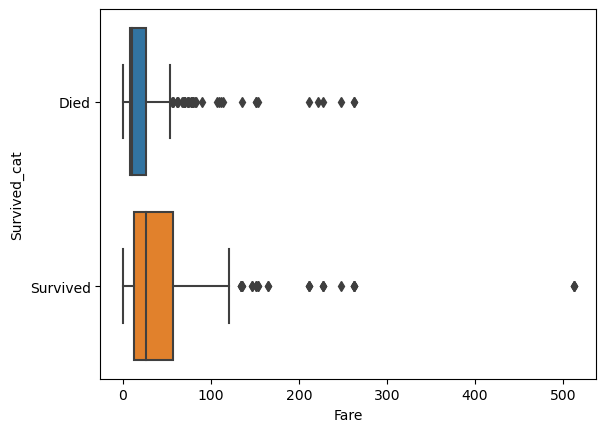

In [8]:
sns.boxplot(x='Fare', data=df, y='Survived_cat')

plt.show()

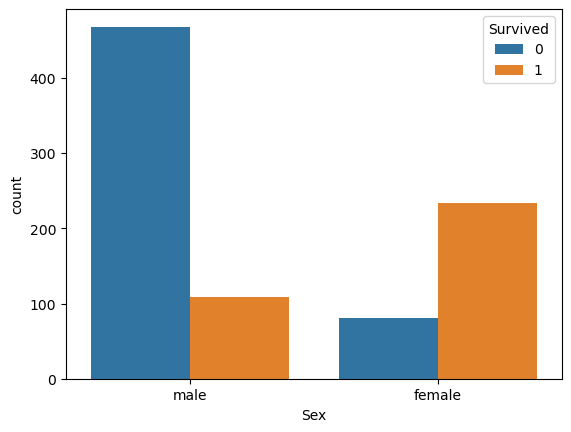

In [10]:
sns.countplot(x='Sex', hue='Survived', data=df)

plt.show()

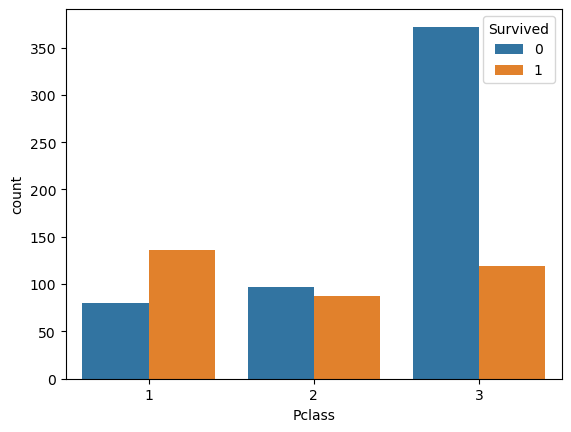

In [14]:
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.show()

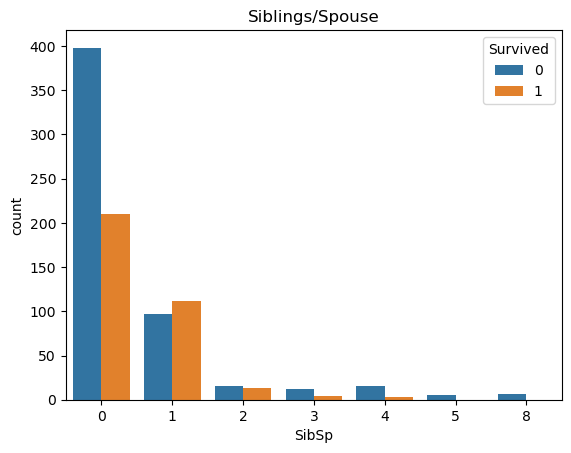

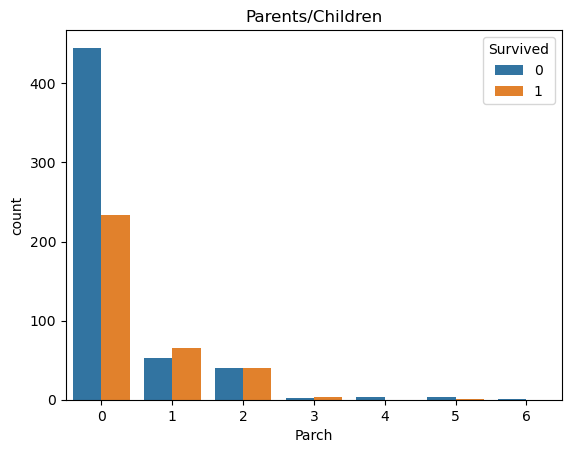

In [17]:
sns.countplot(x='SibSp', hue='Survived', data=df)
plt.title('Siblings/Spouse')
plt.show()

sns.countplot(x='Parch', hue='Survived', data=df)
plt.title('Parents/Children')
plt.show()

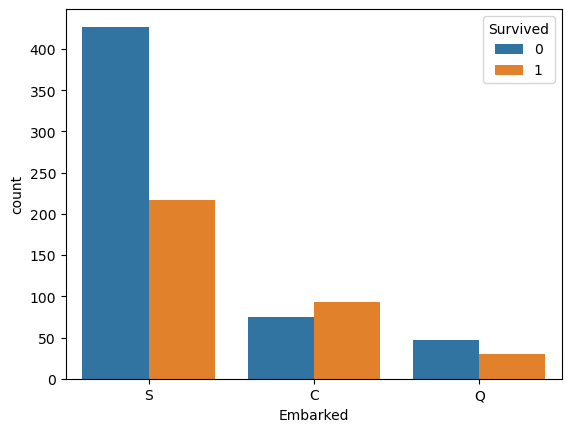

In [16]:
sns.countplot(x='Embarked', hue='Survived', data=df)

plt.show()

In [26]:
likely_df = df.loc[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['Fare'].between(10, 50)) &
    (df['Age'].between(20, 35)) &
    (df['Embarked'] == 'C') &
    ((df['SibSp'].isin([1, 2])) | (df['Parch'].isin([1, 2])))
]

likely_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived_cat
539,540,1,1,"Frolicher, Miss. Hedwig Margaritha",female,22.0,0,2,13568,49.5,B39,C,Survived


In [28]:
unlikely_df = df.loc[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['Fare'].between(10, 20)) &
    (df['Age'].between(20, 40)) &
    (df['Embarked'] == 'S') &
    ((df['SibSp'] == 0) | (df['Parch'] == 0))
]

unlikely_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived_cat
206,207,0,3,"Backstrom, Mr. Karl Alfred",male,32.0,1,0,3101278,15.85,NaN,S,Died
253,254,0,3,"Lobb, Mr. William Arthur",male,30.0,1,0,A/5. 3336,16.10,NaN,S,Died
353,354,0,3,"Arnold-Franchi, Mr. Josef",male,25.0,1,0,349237,17.80,NaN,S,Died
403,404,0,3,"Hakkarainen, Mr. Pekka Pietari",male,28.0,1,0,STON/O2. 3101279,15.85,NaN,S,Died
605,606,0,3,"Lindell, Mr. Edvard Bengtsson",male,36.0,1,0,349910,15.55,NaN,S,Died
